_(for the [[The Worldwide Air-Transportation Network]] website)_

## Chain Rule for Periodic Orbits

> **Chain rule for function composition:** $(f \circ g)' (x) = f'(g(x)) \cdot g'(x)$

When $f=g$ (composing a function with itself):

$$
(f^2)'(x) = (f(f(x)))'
$$

_($f^2$ is **f composed with f**, not f squared, see [[Linear Systems]])_

Applying the chain rule:

$$
(f^2)'(x) = f'(f(x)) \cdot f'(x)
$$

### Application to Period-2 Orbits

If $\{ p_{1},p_{2} \}$ is a period-2 orbit of $f$, then:

- $f(p_{1})=p_{2}$ and $f(p_{2})=p_{1}$
- Equivalently: $f^2(p_{1})=p_{1}$ and $f^2(p_{2}) = p_{2}$

Applying the chain rule to find the derivative at each point:

$$
\begin{align*}
(f^2)'(p_{1}) &= f'(f(p_{1})) \cdot f'(p_{1}) \\
&= f'(p_{2}) \cdot f'(p_{1})
\end{align*}
$$

Similarly:

$$
(f^2)'(p_{2}) = f'(f(p_{2})) \cdot f'(p_{2}) = f'(p_{1}) \cdot f'(p_{2})
$$

**Key observation:** Both derivatives are equal: $(f^2)'(p_{1}) = (f^2)'(p_{2}) = f'(p_{1}) \cdot f'(p_{2})$

This generalizes to any period-$n$ orbit. For a period-7 orbit, we compute:

$$
(f^7)'(p_{i}) = f'(p_{7}) \cdot f'(p_{6}) \cdot \ldots \cdot f'(p_{1})
$$

---

## Stability of Periodic Orbits

**Stability** is a collective property of the entire orbit. All points in a periodic orbit share the same stability:

$$
(f^{k})'(p_{i}) = (f^{k})'(p_{j}) \quad \forall_{i,j}
$$

for any periodic orbit $\{ p_{1},p_{2},\dots,p_{k} \}$.

In plain English, every point in a period-$k$ orbit has the same derivative when we apply $f^k$, because they all cycle through the same sequence of local derivatives.

> **Definition:** A periodic orbit $\{ p_{1},p_{2},\dots,p_{k} \}$ is a [[Attracting fixed point|sink]] (attracting) if $\left|f'(p_{k}) \cdot f'(p_{k-1}) \cdot \ldots \cdot f'(p_{1})\right| < 1$

The orbit is a **source** (repelling) if the product has absolute value greater than 1.

---

## Higher-Order Compositions

As you take higher compositions ($f^3, f^4, f^7, \ldots$), the pattern continues:

**For $f^n$, the fixed points include:**
- All original fixed points of $f$
- All period-2 orbits (if $n$ is even, or any multiple of 2)
- All period-3 orbits (if $n$ is a multiple of 3)
- Generally, all period-$k$ orbits where $k$ divides $n$

**Example:** The graph of $f^6$ will intersect $y = x$ at points corresponding to:
- Period-1 orbits (original fixed points)
- Period-2 orbits ($6 = 2 \times 3$)
- Period-3 orbits ($6 = 3 \times 2$)
- Period-6 orbits

Each higher composition reveals more structure, turning periodic orbits into fixed points that can be analyzed using the chain rule.

---

## Cobweb Plot Generator

Used claude to generate a little tool, mess around with parameter values to see what happens

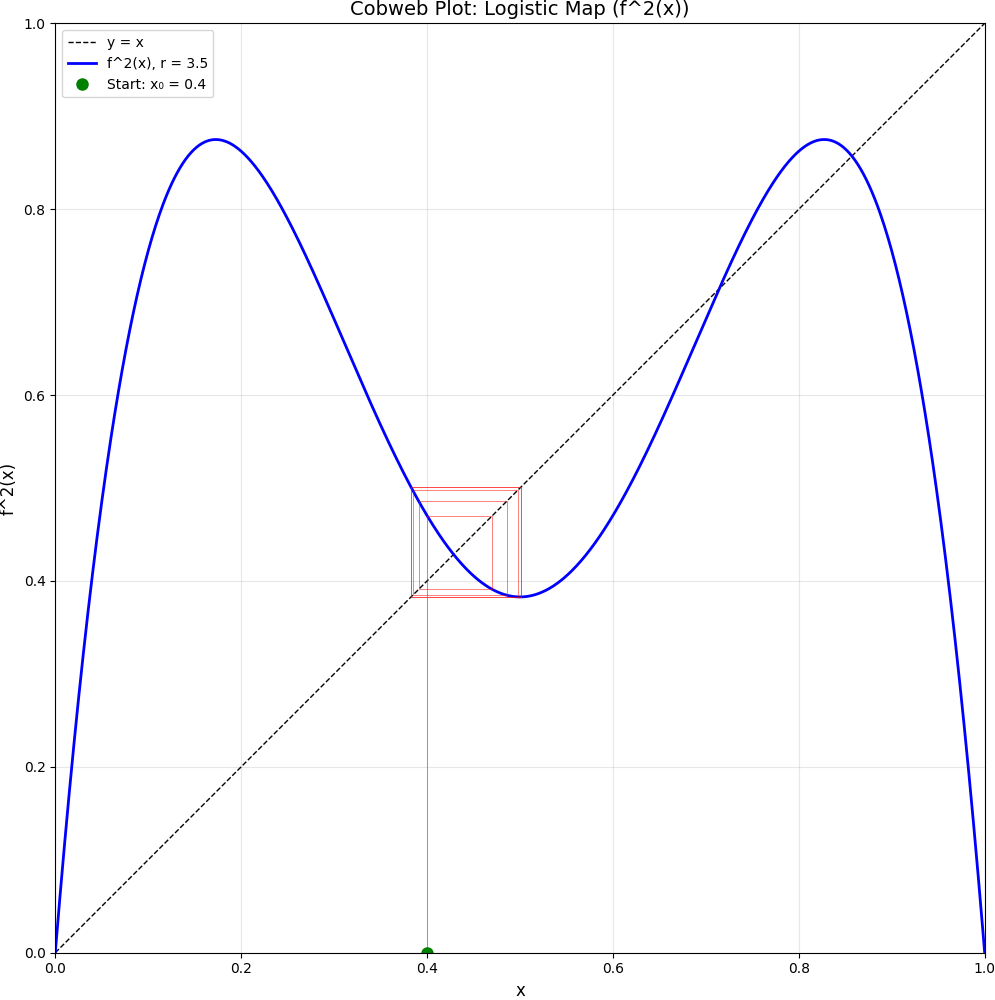

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============ PARAMETERS ============
r = 3.5              # Logistic map parameter (0 < r <= 4)
x0 = 0.4             # Initial condition (0 < x0 < 1)
n_iterations = 50    # Number of iterations to plot
composition_order = 2  # Order of composition (1 = f, 2 = f^2, etc.)
# ====================================

def logistic_map(x, r):
    """Single iteration of logistic map: f(x) = r*x*(1-x)"""
    return r * x * (1 - x)

def composed_map(x, r, n):
    """Apply logistic map n times: f^n(x)"""
    result = x
    for _ in range(n):
        result = logistic_map(result, r)
    return result

# Generate the function curve
x_vals = np.linspace(0, 1, 1000)
y_vals = np.array([composed_map(x, r, composition_order) for x in x_vals])

# Generate cobweb plot trajectory
x_cobweb = [x0]
y_cobweb = [0]

for i in range(n_iterations):
    # Move vertically to the function
    x_cobweb.append(x_cobweb[-1])
    y_cobweb.append(composed_map(x_cobweb[-1], r, composition_order))

    # Move horizontally to y=x line
    x_cobweb.append(y_cobweb[-1])
    y_cobweb.append(y_cobweb[-1])

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Plot y = x line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='y = x')

# Plot the function
order_label = f'f(x)' if composition_order == 1 else f'f^{composition_order}(x)'
ax.plot(x_vals, y_vals, 'b-', linewidth=2,
        label=f'{order_label}, r = {r}')

# Plot cobweb
ax.plot(x_cobweb, y_cobweb, 'r-', linewidth=0.5, alpha=0.7)
ax.plot(x0, 0, 'go', markersize=8, label=f'Start: x₀ = {x0}')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel(order_label, fontsize=12)
ax.set_title(f'Cobweb Plot: Logistic Map ({order_label})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

**Try these parameter combinations:**
- `r = 2.8, composition_order = 1`: Converges to fixed point
- `r = 3.2, composition_order = 1`: Period-2 orbit (oscillates)
- `r = 3.2, composition_order = 2`: Period-2 becomes fixed points
- `r = 3.5, composition_order = 1`: Period-4 orbit
- `r = 4.0, composition_order = 1`: Chaotic behavior

---